# Processamento de Linguagem Natural

In [5]:
from pathlib import Path


from dotenv import load_dotenv

import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from gensim import corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models.ldamodel import LdaModel

from nltk.stem import PorterStemmer, SnowballStemmer
from numpy.ma.core import left_shift
from seaborn import heatmap

from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [6]:
DATASET_DIR = 'dataset'

ROOT_DIR = Path().resolve().__str__()
DATASET_PATH = Path(ROOT_DIR).joinpath(DATASET_DIR)

load_dotenv(ROOT_DIR + 'secrets.env')

False

In [7]:
!kaggle auth login

Your browser has been opened to visit:
  https://www.kaggle.com/api/v1/oauth2/authorize?response_type=code&client_id=kagglesdk&redirect_uri=http%3A%2F%2Flocalhost%3A8993&scope=resources.admin%3A%2A&state=ca01ae4b-6a83-4cd9-997c-aea16144bec2&code_challenge=MdljszM2mDdjuOpsgj_cf_ng6OL_592aYSIH1jn9lr4%3D&code_challenge_method=S256&response_mode=query



You are now logged in as [renataabreu]



127.0.0.1 - - [28/May/2026 16:13:09] "GET /?code=CfDJ8G82xNY93phHtA6xMwIf8xOqa_7cb8dXfKVeBcwr2BqF6nWeyWXFCnCg8mZ6Qn8Zc9nPR0DdLH6bax8lpGJXIdlA7o97kF4TioQ4ZP6F_oQH1vea-MFlJJWhWqAxdQY0Y7CTPO7p_Rbk3MmgLR7HIek2FvZucR3dkNw5sD8lsCUWTTXcg9IPsR46oALbHReA8VHAPcnaXso_WHUzIhihppgRkELQP6W6wuT8TImLJk50h6XmOh8qMxrPuL7bnm_t0VKPJsk-Y9itXysuajGhv5_4hR0hzI_fRwhGjsfQoakc2QibkFhx-pB37VclDQ&state=ca01ae4b-6a83-4cd9-997c-aea16144bec2 HTTP/1.1" 200 -


In [8]:
import kaggle

kaggle.api.authenticate()
Path.mkdir(Path(DATASET_PATH), parents=True, exist_ok=True)
kaggle.api.dataset_download_files('olistbr/brazilian-ecommerce', path=DATASET_PATH, unzip=True, quiet=False)

print("Path to dataset files: ", DATASET_PATH)

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


100%|██████████| 42.6M/42.6M [00:02<00:00, 15.6MB/s]



Path to dataset files:  C:\Users\Renata\DataspellProjects\Infnet-MIT-IA-PLN-PD_26E2_\dataset


## Normalização

In [114]:
reviews = pd.read_csv(DATASET_PATH.joinpath('olist_order_reviews_dataset.csv'), encoding='utf-8')
reviews.dropna(axis=0, subset=['review_comment_message'], inplace=True)
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01
...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43


In [169]:
import numpy as np

nltk.download('stopwords')

stop_words = stopwords.words('portuguese')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Renata\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
def clean_text_as_list(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return [token for token in tokens if token not in stop_words]

def clean_text_as_str(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return ' '.join((token for token in tokens if token not in stop_words))

Aplica o mesmo preprocessamento, porém o retorno é diferente para uso distintos (_list_ e _string_).

In [112]:
cols = ['review_comment_title', 'review_comment_message']
reviews['tokens'] = (reviews[cols].astype(str)
                     .apply(lambda x:
                                                 ' '.join([str(x['review_comment_title']), str(x['review_comment_message'] if str(x['review_comment_title']) is not None else str(x['review_comment_message']))]), axis=1)
                     .apply(clean_text_as_list))

In [113]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,tokens
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,"[recebi, bem, antes, prazo, estipulado]"
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,"[parabens, lojas, lannister, adorei, comprar, ..."
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47,"[recomendo, aparelho, eficiente, site, marca, ..."
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22,"[pouco, travando, valor, boa]"
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01,"[super, recomendo, vendedor, confiavel, produt..."
...,...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51,"[produto, recebi, acordo, compra, realizada]"
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23,"[entregou, dentro, prazo, produto, chegou, con..."
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06,"[produto, enviado, existe, venda, certeza, fic..."
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,"[excelente, mochila, entrega, super, rapida, s..."


<Axes: >

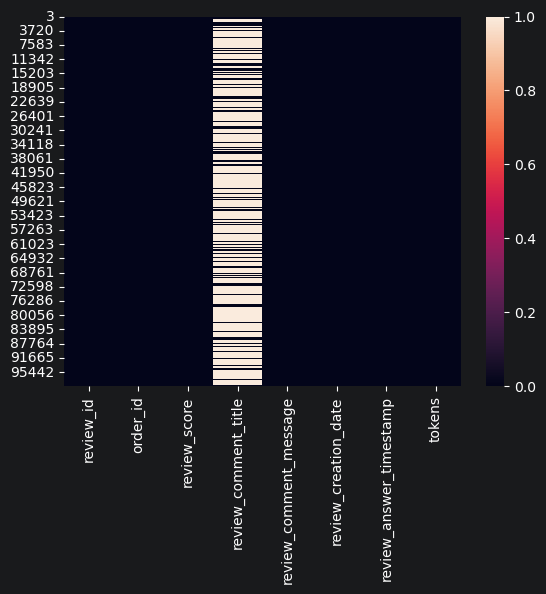

In [14]:
sb.heatmap(reviews.isna())

## Stemming / Snowball

In [15]:
!python -m spacy download pt_core_news_md

     ---------------------------------------- 0.0/42.4 MB ? eta -:--:--
     ---------- ---------------------------- 11.5/42.4 MB 65.5 MB/s eta 0:00:01
     ------------------- ------------------- 21.5/42.4 MB 75.6 MB/s eta 0:00:01
     ----------------------- --------------- 25.2/42.4 MB 44.2 MB/s eta 0:00:01
     ------------------------ -------------- 27.0/42.4 MB 34.9 MB/s eta 0:00:01
     -------------------------- ------------ 29.1/42.4 MB 33.6 MB/s eta 0:00:01
     ------------------------------ -------- 33.3/42.4 MB 27.8 MB/s eta 0:00:01
     --------------------------------- ----- 36.2/42.4 MB 25.8 MB/s eta 0:00:01
     ----------------------------------- --- 39.1/42.4 MB 24.1 MB/s eta 0:00:01
     --------------------------------------  41.7/42.4 MB 22.5 MB/s eta 0:00:01
     ---------------------------------------- 42.4/42.4 MB 21.6 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')


In [16]:
from collections import Counter
import spacy
snowball_pt = SnowballStemmer(language="portuguese")
nlp_pt = spacy.load("pt_core_news_md")
tokens_rad = []
for tokens in reviews['tokens']:
    for token in list(tokens):
        token = snowball_pt.stem(token)
        tokens_rad.append(token)

for tuple_tokens in Counter(tokens_rad).most_common(50):
    print(tuple_tokens)

('produt', 20919)
('entreg', 12456)
('praz', 8663)
('compr', 7499)
('receb', 6805)
('cheg', 6607)
('recom', 6067)
('antes', 5680)
('bom', 5661)
('otim', 4857)
('vei', 3380)
('rap', 3143)
('bem', 3133)
('loj', 2943)
('qualidad', 2882)
('gost', 2597)
('sup', 2482)
('tud', 2479)
('aind', 2414)
('excelent', 2387)
('ate', 2093)
('ped', 2067)
('perfeit', 1641)
('esper', 1552)
('boa', 1524)
('dentr', 1476)
('satisfeit', 1436)
('atend', 1418)
('outr', 1348)
('dia', 1317)
('lannist', 1281)
('por', 1233)
('sit', 1212)
('previst', 1189)
('correi', 1136)
('parabens', 1126)
('tod', 1093)
('falt', 1072)
('cert', 1072)
('aguard', 1067)
('lind', 1065)
('problem', 1063)
('pois', 1050)
('corret', 1033)
('ador', 999)
('sempr', 979)
('demor', 979)
('conform', 956)
('obrig', 942)
('dias', 932)


## Lematização

In [115]:
reviews['review_comment_transformed'] = (reviews[cols].astype(str)
                     .apply(lambda x:
                                ' '.join([str(x['review_comment_title']), str(x['review_comment_message'] if str(x['review_comment_title']) != 'nan' else str(x['review_comment_message']))]), axis=1
                            )
       )

In [100]:
docs = (reviews['review_comment_transformed'].astype(str)
                    .apply(clean_text_as_str)
       )

In [105]:
tokens_lem = []

for doc in docs:
    lemanizer = nlp_pt(doc)
    for lem in lemanizer:
        tokens_rad.append(lem.lemma_)

for tuple_tokens in Counter(tokens_lem).most_common(500):
    print(tuple_tokens)

## Analise de Sentimento

### Classificação supervisionada com Naive Bayes e Vetorização com TfidfVectorizer
### Categorias

- 1 = Péssimo
- 2 = Ruim
- 3 = Regular
- 4 = Bom
- 5 = Excelente

In [19]:
categories = dict({
    1: 'Péssimo',
    2: 'Ruím',
    3: 'Regular',
    4: 'Bom',
    5: 'Excelente',
})

In [ ]:
tokens_lem_by_rate = []
tokens_lem = []

for i, rate in enumerate(categories.keys()):
    filtered = reviews.query('review_score == ' + str(rate))
    for review in pd.DataFrame({'tokens': filtered.review_comment_transformed}).values:
        tokens = clean_text_as_str(review)
        lemanizer = nlp_pt(tokens)
        for lem in lemanizer:
            tokens_lem.append(lem.lemma_)
    tokens_lem_by_rate.append({'rate': rate, 'tokens': tokens_lem.copy()})
    tokens_lem.clear()

In [84]:
model_rate = MultinomialNB()
vectorizer_rate = TfidfVectorizer()

keys = list(pd.DataFrame(tokens_lem_by_rate)['rate'].apply(lambda x: str(x)))
values = list(pd.DataFrame(tokens_lem_by_rate)['tokens'].apply(lambda x: str(x)))
X_rate = vectorizer_rate.fit_transform(values)

model_rate.fit(X_rate, list(keys))

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [110]:
predictions_rate = []
rates_tf_idf_rate = []
for review in docs:
    vec = vectorizer_rate.transform([review])
    _X = model_rate.predict(vec)
    rates_tf_idf_rate.append(int(_X[0]))
    # rates_tf_idf.append({"tf-idf": model.predict(vec)[0]})
    predictions_rate.append({"review": review, "nota": _X[0], "categoria": categories.get(int(_X[0]))})


In [102]:
pd.DataFrame(predictions_rate)

,review,nota,categoria
0,recebi bem antes prazo estipulado,5,Excelente
1,parabens lojas lannister adorei comprar intern...,5,Excelente
2,recomendo aparelho eficiente site marca aparel...,5,Excelente
3,pouco travando valor boa,3,Regular
4,super recomendo vendedor confiavel produto ent...,5,Excelente
...,...,...,...
40972,produto recebi acordo compra realizada,1,Péssimo
40973,entregou dentro prazo produto chegou condicoes...,4,Bom
40974,produto nao enviado nao existe venda certeza f...,1,Péssimo
40975,excelente mochila entrega super rapida super r...,5,Excelente


In [20]:
model = MultinomialNB()
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(categories.values())

model.fit(X, list(categories.keys()))

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [85]:
predictions = []
rates_tf_idf = []
for review in docs:
    vec = vectorizer.transform([review])
    rates_tf_idf.append(model.predict(vec)[0])
    # rates_tf_idf.append({"tf-idf": model.predict(vec)[0]})
    predictions.append({"review": review, "nota": model.predict(vec)[0], "categoria": categories.get(model.predict(vec)[0])})


In [93]:
pd.DataFrame(predictions)

,review,nota,categoria
0,recebi bem antes prazo estipulado,5,Excelente
1,parabens lojas lannister adorei comprar intern...,5,Excelente
2,recomendo aparelho eficiente site marca aparel...,5,Excelente
3,pouco travando valor boa,3,Regular
4,super recomendo vendedor confiavel produto ent...,5,Excelente
...,...,...,...
40972,produto recebi acordo compra realizada,1,Péssimo
40973,entregou dentro prazo produto chegou condicoes...,4,Bom
40974,produto nao enviado nao existe venda certeza f...,1,Péssimo
40975,excelente mochila entrega super rapida super r...,5,Excelente


In [ ]:
predictions = []
rates_tf_idf = []

for rate in enumerate(categories):
    for review in reviews.query('review_score = ' + rate.__str__()):
    # for review in reviews:
        vec = vectorizer.transform([review.tokens])
        rates_tf_idf.append(model.predict(vec)[0])
        # rates_tf_idf.append({"tf-idf": model.predict(vec)[0]})
        predictions.append({"review": review, "nota": model.predict(vec)[0], "categoria": categories.get(model.predict(vec)[0])})

### Vetorizar por Rate (*)

In [ ]:
tokens_lem_by_rate = []
tokens_lem = []

for i, rate in enumerate(categories.keys()):
    filtered = reviews.query('review_score == ' + str(rate))
    tokens_lem.clear()
    for review in pd.DataFrame({'tokens': filtered.review_comment_transformed}).values:
        tokens = clean_text_as_str(review)
        lemanizer = nlp_pt(tokens)
        for lem in lemanizer:
            tokens_lem.append(lem.lemma_)
    tokens_lem_by_rate.append({'rate': rate, 'tokens': tokens_lem})

In [121]:
analyzer = SentimentIntensityAnalyzer()
WORDS_PER_CATEGORY = 30

for tokens_lem_rate in iter(tokens_lem_by_rate):
    print('rate: ' + tokens_lem_rate.get('rate').__str__())
    for tuple_tokens in Counter(tokens_lem_rate.get('tokens')).most_common(WORDS_PER_CATEGORY):
        print(tuple_tokens, end="\n")
        analyzer.lexicon.update({
            tuple_tokens.__getitem__(0): tokens_lem_rate.get('rate'),
        })
    print("\n")


rate: 1
('nao', 7570)
('produto', 6000)
('entregar', 2559)
('recebi', 2273)
('comprar', 1940)
('chegar', 1313)
('vir', 1258)
('ate', 1230)
('ainda', 1206)
('receber', 1187)
('dia', 988)
('pedir', 953)
('loja', 766)
('compra', 746)
('prazo', 731)
('dois', 675)
('agora', 629)
('outro', 618)
('querer', 529)
('pessimo', 484)
('nada', 480)
('recomendar', 478)
('lannister', 469)
('fazer', 463)
('apenas', 443)
('pois', 420)
('errar', 416)
('entrega', 414)
('enviar', 410)
('contato', 409)


rate: 2
('nao', 1436)
('produto', 1316)
('entregar', 578)
('vir', 481)
('comprar', 423)
('recebi', 413)
('chegar', 331)
('ainda', 225)
('prazo', 220)
('pedir', 211)
('receber', 202)
('dia', 197)
('bom', 177)
('ate', 176)
('por', 174)
('dois', 166)
('outro', 164)
('loja', 158)
('compra', 143)
('entrega', 138)
('gostar', 137)
('qualidade', 122)
('recomendar', 114)
('faltar', 112)
('esperar', 107)
('fazer', 107)
('apenas', 104)
('pois', 103)
('demorar', 96)
('cor', 92)


rate: 3
('produto', 1862)
('nao', 1615)

In [122]:
analyzer = SentimentIntensityAnalyzer()
WORDS_PER_CATEGORY = 200

import numpy.ma.core as math

for tokens_lem_rate in iter(tokens_lem_by_rate):
    print('rate: ' + tokens_lem_rate.get('rate').__str__())
    for tuple_tokens in Counter(tokens_lem_rate.get('tokens')).most_common(WORDS_PER_CATEGORY):
        _weight = math.power(float(tuple_tokens.__getitem__(1)),  float(tokens_lem_rate.get('rate')*-1))
        print(tuple_tokens, end="\n")
        _lex = analyzer.lexicon.get(tuple_tokens.__getitem__(0))
        if _lex is None:
            analyzer.lexicon.update({
                tuple_tokens.__getitem__(0): float(tokens_lem_rate.get('rate') + _weight) -1,
            })
        else:
             analyzer.lexicon.update({
                tuple_tokens.__getitem__(0): float(_lex + _weight),
            })

        # analyzer.lexicon.update({
        #     tuple_tokens.__getitem__(0): tokens_lem_rate.get('rate'),
        # })
    print("\n")


rate: 1
('nao', 7570)
('produto', 6000)
('entregar', 2559)
('recebi', 2273)
('comprar', 1940)
('chegar', 1313)
('vir', 1258)
('ate', 1230)
('ainda', 1206)
('receber', 1187)
('dia', 988)
('pedir', 953)
('loja', 766)
('compra', 746)
('prazo', 731)
('dois', 675)
('agora', 629)
('outro', 618)
('querer', 529)
('pessimo', 484)
('nada', 480)
('recomendar', 478)
('lannister', 469)
('fazer', 463)
('apenas', 443)
('pois', 420)
('errar', 416)
('entrega', 414)
('enviar', 410)
('contato', 409)
('faltar', 408)
('site', 408)
('saber', 388)
('aguardar', 384)
('gostar', 370)
('ir', 369)
('esperar', 364)
('nenhum', 358)
('problema', 350)
('qualidade', 341)
('pra', 331)
('momento', 322)
('por', 318)
('fiz', 311)
('nota', 303)
('correio', 302)
('diferente', 300)
('dinheiro', 295)
('retorno', 287)
('dar', 286)
('resposta', 281)
('bom', 279)
('unidade', 266)
('ter', 266)
('defeito', 262)
('mandar', 261)
('entrar', 260)
('cancelar', 255)
('empresa', 252)
('hoje', 242)
('vez', 242)
('mercadoria', 242)
('dizer

### VaderSentment

In [114]:
analyzer = SentimentIntensityAnalyzer()

# adiciona palavras em português
analyzer.lexicon.update({

    "excelente": 5,
    "qualidade": 5,
    "parabens": 5,
    "rapido": 5,
    "recomendar": 5,
    "resistente": 5,
    "otimo": 5,
    "super": 5,

    "bom": 4,
    "recebi": 4,
    "chegou": 4,
    "boa": 4,
    "obrigado": 4,
    "bonito": 4,

    "funcionar": 3,

    "muito ruim": 2,
    "ruim": 2,
    "mal": 2,
    "danificar": 2,
    "defeito": 2,
    "pequeno": 2,

    "pessimo": 1,
    "problema": 1,
    "horrivel": 1,
    "errar": 1,
    "retornar": 1,
    "cancelei": 1,
    "cancelar": 2,
    "reembolso": 1,
    "devolucao": 1,
    "devolver": 1,
})

In [115]:
def compound_to_rating(compound):
    if compound <= -0.6:
        return 1
    elif compound <= -0.2:
        return 2
    elif compound <= 0.2:
        return 3
    elif compound <= 0.6:
        return 4
    else:
        return 5

In [116]:
rates_vader = []
predictions = []
for review in docs:
    vader = analyzer.polarity_scores(review)
    compound = vader['compound']
    rating = compound_to_rating(compound)
    rates_vader.append(rating)

    predictions.append({"review": review, "nota": rating, "categoria": categories.get(rating)})


In [117]:
pd.DataFrame(predictions)

,review,nota,categoria
0,recebi bem antes prazo estipulado,5,Excelente
1,parabens lojas lannister adorei comprar intern...,5,Excelente
2,recomendo aparelho eficiente site marca aparel...,3,Regular
3,pouco travando valor boa,5,Excelente
4,super recomendo vendedor confiavel produto ent...,5,Excelente
...,...,...,...
40972,produto recebi acordo compra realizada,5,Excelente
40973,entregou dentro prazo produto chegou condicoes...,5,Excelente
40974,produto nao enviado nao existe venda certeza f...,3,Regular
40975,excelente mochila entrega super rapida super r...,5,Excelente


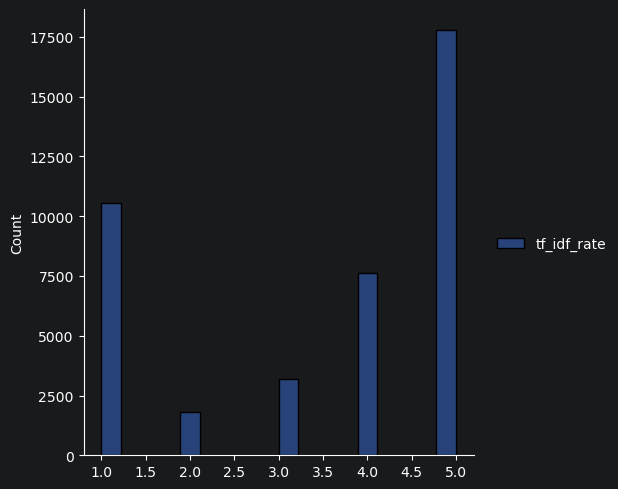

In [111]:
sb.displot(data=pd.DataFrame({'tf_idf_rate': rates_tf_idf_rate}))

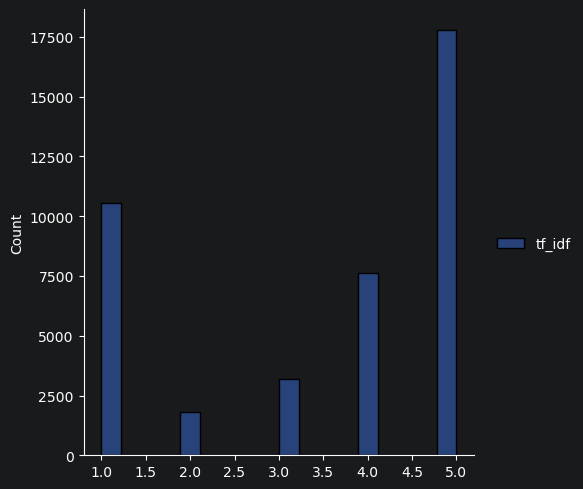

In [112]:
sb.displot(data=pd.DataFrame({'tf_idf': rates_tf_idf}))

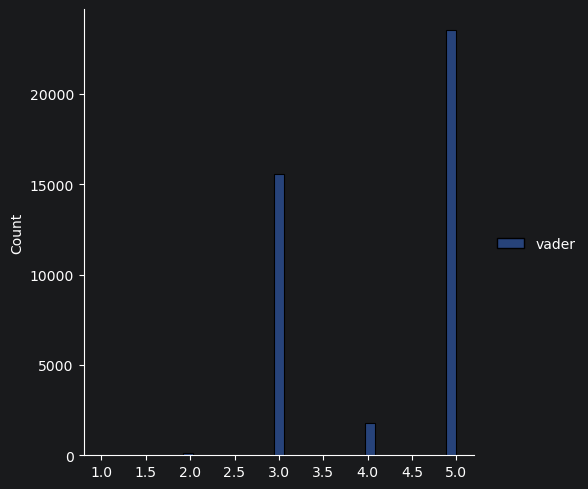

In [123]:
sb.displot(data=pd.DataFrame({'vader': rates_vader}))

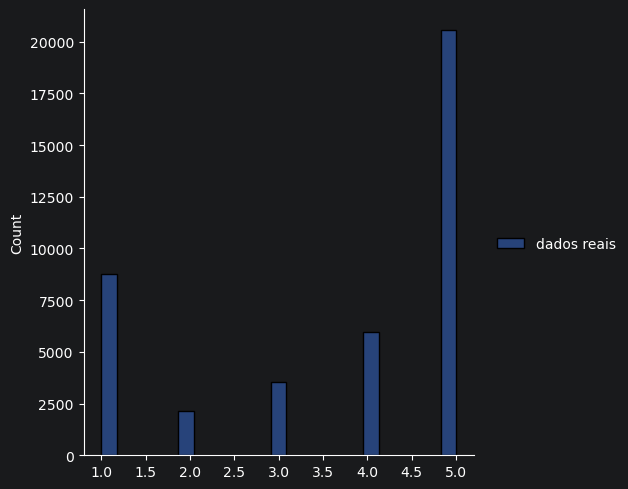

In [120]:
sb.displot(data=pd.DataFrame({'dados reais': reviews.review_score}))

In [68]:
pd.DataFrame({'score': reviews.review_score, 'review': reviews.review_comment_message}).query('score == 1')

,score,review
19,1,Péssimo
29,1,Não gostei ! Comprei gato por lebre
32,1,Sempre compro pela Internet e a entrega ocorre...
39,1,Nada de chegar o meu pedido.
51,1,recebi somente 1 controle Midea Split ESTILO.\...
...,...,...
99094,1,Gostaria de saber porque meu produto ainda não...
99141,1,Ate hoje dia 21/10/2017 o pedido não foi entre...
99155,1,Eu recebi o seguinte email e preciso saber com...
99169,1,Boa tarde. \r\nNão recebo todos os produtos fa...
